In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from tensorflow.keras import utils  # utils.to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# 1. 로지스틱 회귀분석(이진분류)
## 1.1 데이터셋 생성 및 전처리

In [3]:
df = pd.read_csv('data/pima-indians-diabetes.csv', 
                 header=None, 
                 comment= '#')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df[8].value_counts() # 비율이 크게 맞지 않으면, 1인 데이터를 추가로 만들기도 한다

0    500
1    268
Name: 8, dtype: int64

In [16]:
df.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#csv파일로 numpy 로 읽어오기
dataset = np.loadtxt('data/pima-indians-diabetes.csv',
                    encoding='utf-8',
                    delimiter=',')
dataset.shape

(768, 9)

In [5]:
# 데이터분할 : 학습데이터셋(모델학습용) + 테스트데이터셋(모델평가용)
X_train = dataset[:650, :-1]
y_train = dataset[:650, -1]
X_test = dataset[650:, :-1]
y_test = dataset[650:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((650, 8), (650,), (118, 8), (118,))

## 1.2 모델구성

In [66]:
model = Sequential(name='pima_Diabetes_model')
# 레이어 4개(히든-relu, 출력-sig) 8개 -> 32 -> 16 -> 16 -> 1
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "pima_Diabetes_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 32)                288       
                                                                 
 dense_23 (Dense)            (None, 16)                528       
                                                                 
 dense_24 (Dense)            (None, 16)                272       
                                                                 
 dense_25 (Dense)            (None, 1)                 17        
                                                                 
Total params: 1,105
Trainable params: 1,105
Non-trainable params: 0
_________________________________________________________________


## 1.3 학습과정 설정

In [67]:
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['binary_accuracy']) # 성능 평가를 할 때 나오는 값. 리스트 안에 넣어야 한다

## 1.4 학습하기

In [68]:
%%time 
 # 셀의 수행 완료 시간 측정
# hist1 = model.fit(X_train, y_train, # 훈련데이터
#                 epochs=200, # 학습횟수
#                 batch_size=350, # 한번에 읽어들이는 데이터 양
#                 # validation_data= (X_test, y_test), # 검증데이터를 직접 입력하거나
#                 # validation_split= 0.1,               # 훈련데이터의 일정 비율을 설정할 수 있음
#                 verbose=0              
#                 )
hist2 = model.fit(X_train, y_train, # 훈련데이터
                epochs=2000, # 학습횟수
                batch_size=350, # 한번에 읽어들이는 데이터 양
                # validation_data= (X_test, y_test), # 검증데이터를 직접 입력하거나
                validation_split= 0.1,               # 훈련데이터의 일정 비율을 설정할 수 있음
                verbose=0              
                )

CPU times: total: 1min 10s
Wall time: 54.9 s


## 1. 5 모델 평가하기(학습과정 보기, 평가, 교차표)

In [28]:
hist1.history.keys(), hist2.history.keys()

(dict_keys(['loss', 'binary_accuracy']),
 dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy']))

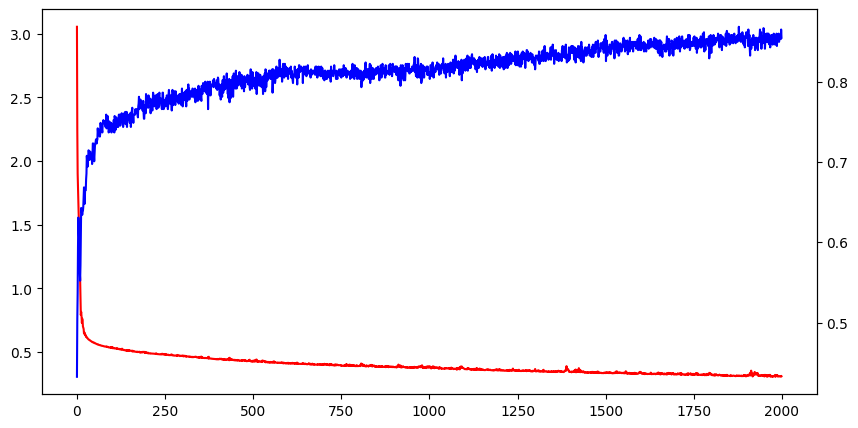

In [70]:
# 학습과정 표시- 그래프로 (학습데이터에 대한 loss / accuracy)

fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist2.history['loss'], 'r')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist2.history.get('binary_accuracy'), 'b')

In [71]:
# 모델 평가
# model.evaluate(테스트데이터x, 테스트데이터y)
model.evaluate(X_test, y_test)

4/4 [==============================] - 0s 2ms/step - loss: 0.8723 - binary_accuracy: 0.7288


[0.8722516894340515, 0.7288135886192322]

### ※ 교차표(Crosstab) = 혼돈 행렬(Confusion Matrix) = 성능평가지표
- 테스트 데이터 셋의 실제값과 예측값으로 작성된 교차표<br>

<img src='https://velog.velcdn.com/images/jjw9599/post/271fc800-bffb-4e8f-83cf-d55d18ede61a/image.png'
         width=600, style="float: left;">
<div style="clear: both;"></div>

- accuracy(정확도) = (TN + TP) / (TN + FP + FN + TP)
- precision(정밀도) = (TP) / (FP + TP)
    * precision을 높이려면 확실한 것만 Positive로 예측, 실제 1이어도 애매하면 패스 : 고객은 편함 / 회사는 비용 증가
- recall(재현율) = TP / (FN + TP)
    * recall을 높이려면 조금이라도 가능성이 있으면 Positive로 예측 : 고객은 불만 / 회사는 비용 감소
- precision과 recall 반비례 관계이므로 적적한 지점을 찾는게 필요하여 f1-score를 사용하기도 한다
- fl score = recall과 precision의 조화평균
    * 2 * { ( recall * precision ) / (recall + precision ) }


In [72]:
# 실제값 : y-test(68개)
# 예측값
y_hat = (model.predict(X_test)>=0.5).astype(float)

4/4 [==============================] - 0s 2ms/step


In [73]:
# 혼동행렬을 손수 그려보자

TN = 0  # 실제 0을 0으로 예측한 값(맞은 경우 - T)
FP = 0  # 실제 0을 1로 예측한 값 (틀린 경우 - F)
FN = 0  # 실제 1을 0으로 예측한 값 (틀림 - F)
TP = 0  # 실제 1을 1로 예측한 값 (맞음 - T)

print(y_test.shape, y_hat.shape)

for y, h in zip(y_test, y_hat.reshape(-1)):
    # print(y, h)
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, ' | ',FP)
print(FN, ' | ',TP)



(118,) (118, 1)
62  |  11
21  |  24


In [162]:
# 혼동행렬을 제공해주는 라이브러리를 이용해보자
ctab = pd.crosstab(y_test,   # 실제값
                  y_hat.reshape(-1))  # 예측값 (1차원으로 변환)
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
ctab

# crosstab(교차표)의 매개변수 rownames, colnames로 한번에 그릴수 있다
pd.crosstab(y_test,   # 실제값
            y_hat.reshape(-1),
            rownames=['실제값'],
            colnames=['예측값'])

ValueError: All arrays must be of the same length

In [45]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,
                y_hat.reshape(-1))

array([[56, 17],
       [25, 20]], dtype=int64)

In [75]:

print('accuracy :', (TN + TP) / (TN + FP + FN + TP) )
print('recall :', (TP) / (FN + TP) )
print('precision :', (TP) / (FP + TP) )

accuracy : 0.7288135593220338
recall : 0.5333333333333333
precision : 0.6857142857142857


## 1.6 모델 사용

In [81]:
X_test[87]

array([ 8. , 65. , 72. , 23. ,  0. , 32. ,  0.6, 42. ])

In [161]:
model.predict([[8. , 65. , 72. , 23. ,  0. , 32. ,  0.6, 42.],
              [11.   , 120.   ,  80.   ,  37.   , 150.   ,  42.3  ,   0.785, 48.]])

1/1 [==============================] - 0s 56ms/step


array([[0.7673326 , 0.23266745],
       [0.6235796 , 0.3764204 ]], dtype=float32)

In [84]:
y_test[90]

1.0

# 2. 분류분석
1. 데이터셋 생성 및 전처리 : 훈련셋(600), 검증셋(100), 테스트셋(68)
2. 모델 생성(input8, ouput2) : 출력층 softmax(출력합을 1)
    * model.summary() 파라미터 수와 메모리 확인
3. 모델 학습 과정 : loss="cateforical_crossentropy, metrice=['평가지표'] - 일반적으로 accuracy 사용
4. 모델 학습 : 훈련셋과 검증셋
5. 모델 평가 : 그래프(hist.history), 평가(테스트셋), 교차표(테스트셋)
6. 모델 사용 : predict 결과에 argmax(), 재사용 예정시 모델 저장

## 2.1 데이터셋 생성 및 전처리

In [86]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', encoding='utf-8', delimiter=',')
dataset.shape

(768, 9)

In [89]:
# 훈련셋(600), 검증셋(100), 테스트셋(68)
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]

In [90]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [94]:
# 분류분석을 할때는 타겟변수를 원핫인코딩을 실시한다.
print(y_train[:5])
print(utils.to_categorical(y_train[:5]))
Y_train = utils.to_categorical(y_train)
Y_val = utils.to_categorical(y_val)
Y_test = utils.to_categorical(y_test)
Y_train.shape, Y_val.shape, Y_test.shape

[1. 0. 1. 0. 1.]
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


((600, 2), (100, 2), (68, 2))

## 2.2 모델 구성
- 과적합 줄이는 단계 추가(dropout 추가)

In [101]:
from tensorflow.keras.layers import Dropout

model = Sequential(name='pima_Diabetes_model_class')
# 레이어 6개(히든-relu, 출력-softmax) 8개 -> 32 -> -> 6416 -> 8 -> 1
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))    # 과적합을 해결하고자 두루뭉실하게 넘기려는 방법. 20% 정도 날리겠다.
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))    # 과적합을 해결
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.1))    # 과적합을 해결
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "pima_Diabetes_model_class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_31 (Dense)            (None, 32)                288       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_32 (Dense)            (None, 64)                2112      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_33 (Dense)            (None, 16)                1040      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_34 (Dense)            (None, 8)   

## 2.3 학습과정 설정

In [102]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy']) 

## 2.4 학습하기

In [103]:
hist = model.fit(X_train, Y_train,
                epochs=500,
                validation_data=(X_val, Y_val),
                verbose=1,
                batch_size=300)

Epoch 1/500
2/2 [==============================] - 1s 182ms/step - loss: 2.7913 - accuracy: 0.4917 - val_loss: 0.8630 - val_accuracy: 0.6500
Epoch 2/500
2/2 [==============================] - 0s 40ms/step - loss: 1.9726 - accuracy: 0.5617 - val_loss: 0.8363 - val_accuracy: 0.6600
Epoch 3/500
2/2 [==============================] - 0s 33ms/step - loss: 2.1733 - accuracy: 0.5283 - val_loss: 0.7819 - val_accuracy: 0.6500
Epoch 4/500
2/2 [==============================] - 0s 33ms/step - loss: 1.9200 - accuracy: 0.5767 - val_loss: 0.7805 - val_accuracy: 0.6600
Epoch 5/500
2/2 [==============================] - 0s 33ms/step - loss: 1.5949 - accuracy: 0.5550 - val_loss: 0.7174 - val_accuracy: 0.6700
Epoch 6/500
2/2 [==============================] - 0s 33ms/step - loss: 1.5083 - accuracy: 0.5700 - val_loss: 0.6967 - val_accuracy: 0.6800
Epoch 7/500
2/2 [==============================] - 0s 28ms/step - loss: 1.3146 - accuracy: 0.5667 - val_loss: 0.6856 - val_accuracy: 0.6700
Epoch 8/500
2/2 [==

2/2 [==============================] - 0s 30ms/step - loss: 0.7017 - accuracy: 0.6200 - val_loss: 0.6633 - val_accuracy: 0.6700
Epoch 60/500
2/2 [==============================] - 0s 34ms/step - loss: 0.7098 - accuracy: 0.6250 - val_loss: 0.6627 - val_accuracy: 0.6700
Epoch 61/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6798 - accuracy: 0.6450 - val_loss: 0.6623 - val_accuracy: 0.6700
Epoch 62/500
2/2 [==============================] - 0s 28ms/step - loss: 0.7246 - accuracy: 0.6350 - val_loss: 0.6620 - val_accuracy: 0.6700
Epoch 63/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6852 - accuracy: 0.6217 - val_loss: 0.6615 - val_accuracy: 0.6700
Epoch 64/500
2/2 [==============================] - 0s 28ms/step - loss: 0.7186 - accuracy: 0.6333 - val_loss: 0.6610 - val_accuracy: 0.6700
Epoch 65/500
2/2 [==============================] - 0s 30ms/step - loss: 0.7172 - accuracy: 0.6333 - val_loss: 0.6605 - val_accuracy: 0.6700
Epoch 66/500
2/2 [========

2/2 [==============================] - 0s 31ms/step - loss: 0.6711 - accuracy: 0.6450 - val_loss: 0.6433 - val_accuracy: 0.6700
Epoch 118/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6567 - accuracy: 0.6600 - val_loss: 0.6433 - val_accuracy: 0.6700
Epoch 119/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6856 - accuracy: 0.6400 - val_loss: 0.6434 - val_accuracy: 0.6700
Epoch 120/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6595 - accuracy: 0.6517 - val_loss: 0.6435 - val_accuracy: 0.6700
Epoch 121/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6470 - accuracy: 0.6600 - val_loss: 0.6434 - val_accuracy: 0.6700
Epoch 122/500
2/2 [==============================] - 0s 27ms/step - loss: 0.6679 - accuracy: 0.6583 - val_loss: 0.6432 - val_accuracy: 0.6700
Epoch 123/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6607 - accuracy: 0.6517 - val_loss: 0.6425 - val_accuracy: 0.6700
Epoch 124/500
2/2 [=

Epoch 175/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6433 - accuracy: 0.6683 - val_loss: 0.6301 - val_accuracy: 0.6700
Epoch 176/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6404 - accuracy: 0.6800 - val_loss: 0.6294 - val_accuracy: 0.6700
Epoch 177/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6538 - accuracy: 0.6433 - val_loss: 0.6295 - val_accuracy: 0.6700
Epoch 178/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6406 - accuracy: 0.6600 - val_loss: 0.6293 - val_accuracy: 0.6700
Epoch 179/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6385 - accuracy: 0.6600 - val_loss: 0.6289 - val_accuracy: 0.6700
Epoch 180/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6487 - accuracy: 0.6617 - val_loss: 0.6290 - val_accuracy: 0.6700
Epoch 181/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6450 - accuracy: 0.6567 - val_loss: 0.6291 - val_accuracy: 0.6700
Epoch 

Epoch 233/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6267 - accuracy: 0.6733 - val_loss: 0.6125 - val_accuracy: 0.7200
Epoch 234/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6167 - accuracy: 0.6817 - val_loss: 0.6119 - val_accuracy: 0.7100
Epoch 235/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6260 - accuracy: 0.6850 - val_loss: 0.6118 - val_accuracy: 0.7000
Epoch 236/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6405 - accuracy: 0.6650 - val_loss: 0.6126 - val_accuracy: 0.7000
Epoch 237/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6202 - accuracy: 0.6817 - val_loss: 0.6113 - val_accuracy: 0.7000
Epoch 238/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6419 - accuracy: 0.6500 - val_loss: 0.6111 - val_accuracy: 0.7000
Epoch 239/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6318 - accuracy: 0.6633 - val_loss: 0.6112 - val_accuracy: 0.7000
Epoch 

Epoch 291/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6136 - accuracy: 0.6883 - val_loss: 0.5998 - val_accuracy: 0.6900
Epoch 292/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6287 - accuracy: 0.6700 - val_loss: 0.5995 - val_accuracy: 0.7000
Epoch 293/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6177 - accuracy: 0.6683 - val_loss: 0.5996 - val_accuracy: 0.7000
Epoch 294/500
2/2 [==============================] - 0s 29ms/step - loss: 0.6180 - accuracy: 0.6783 - val_loss: 0.5988 - val_accuracy: 0.7000
Epoch 295/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6065 - accuracy: 0.6567 - val_loss: 0.5985 - val_accuracy: 0.7000
Epoch 296/500
2/2 [==============================] - 0s 28ms/step - loss: 0.6179 - accuracy: 0.6767 - val_loss: 0.5986 - val_accuracy: 0.7000
Epoch 297/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6227 - accuracy: 0.6800 - val_loss: 0.5988 - val_accuracy: 0.7000
Epoch 

Epoch 349/500
2/2 [==============================] - 0s 39ms/step - loss: 0.5916 - accuracy: 0.6917 - val_loss: 0.5929 - val_accuracy: 0.7200
Epoch 350/500
2/2 [==============================] - 0s 29ms/step - loss: 0.5933 - accuracy: 0.6967 - val_loss: 0.5927 - val_accuracy: 0.7200
Epoch 351/500
2/2 [==============================] - 0s 30ms/step - loss: 0.5983 - accuracy: 0.6783 - val_loss: 0.5925 - val_accuracy: 0.7200
Epoch 352/500
2/2 [==============================] - 0s 28ms/step - loss: 0.5929 - accuracy: 0.6850 - val_loss: 0.5925 - val_accuracy: 0.7200
Epoch 353/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6181 - accuracy: 0.6650 - val_loss: 0.5928 - val_accuracy: 0.7200
Epoch 354/500
2/2 [==============================] - 0s 30ms/step - loss: 0.6057 - accuracy: 0.6950 - val_loss: 0.5930 - val_accuracy: 0.7200
Epoch 355/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6108 - accuracy: 0.6867 - val_loss: 0.5928 - val_accuracy: 0.7100
Epoch 

Epoch 407/500
2/2 [==============================] - 0s 31ms/step - loss: 0.6204 - accuracy: 0.6667 - val_loss: 0.5871 - val_accuracy: 0.7200
Epoch 408/500
2/2 [==============================] - 0s 31ms/step - loss: 0.5970 - accuracy: 0.6933 - val_loss: 0.5863 - val_accuracy: 0.7100
Epoch 409/500
2/2 [==============================] - 0s 27ms/step - loss: 0.5919 - accuracy: 0.7017 - val_loss: 0.5863 - val_accuracy: 0.7200
Epoch 410/500
2/2 [==============================] - 0s 31ms/step - loss: 0.5981 - accuracy: 0.6950 - val_loss: 0.5867 - val_accuracy: 0.7200
Epoch 411/500
2/2 [==============================] - 0s 28ms/step - loss: 0.5992 - accuracy: 0.6717 - val_loss: 0.5869 - val_accuracy: 0.7200
Epoch 412/500
2/2 [==============================] - 0s 27ms/step - loss: 0.6011 - accuracy: 0.6700 - val_loss: 0.5864 - val_accuracy: 0.7200
Epoch 413/500
2/2 [==============================] - 0s 30ms/step - loss: 0.5869 - accuracy: 0.6933 - val_loss: 0.5863 - val_accuracy: 0.7100
Epoch 

Epoch 465/500
2/2 [==============================] - 0s 30ms/step - loss: 0.5927 - accuracy: 0.6950 - val_loss: 0.5763 - val_accuracy: 0.7000
Epoch 466/500
2/2 [==============================] - 0s 31ms/step - loss: 0.5775 - accuracy: 0.7067 - val_loss: 0.5763 - val_accuracy: 0.6800
Epoch 467/500
2/2 [==============================] - 0s 30ms/step - loss: 0.5948 - accuracy: 0.6800 - val_loss: 0.5769 - val_accuracy: 0.7100
Epoch 468/500
2/2 [==============================] - 0s 29ms/step - loss: 0.5763 - accuracy: 0.7100 - val_loss: 0.5772 - val_accuracy: 0.7100
Epoch 469/500
2/2 [==============================] - 0s 31ms/step - loss: 0.5977 - accuracy: 0.7000 - val_loss: 0.5756 - val_accuracy: 0.6900
Epoch 470/500
2/2 [==============================] - 0s 32ms/step - loss: 0.5735 - accuracy: 0.7000 - val_loss: 0.5748 - val_accuracy: 0.6900
Epoch 471/500
2/2 [==============================] - 0s 30ms/step - loss: 0.5990 - accuracy: 0.6817 - val_loss: 0.5750 - val_accuracy: 0.7100
Epoch 

## 2.5 모델 평가하기

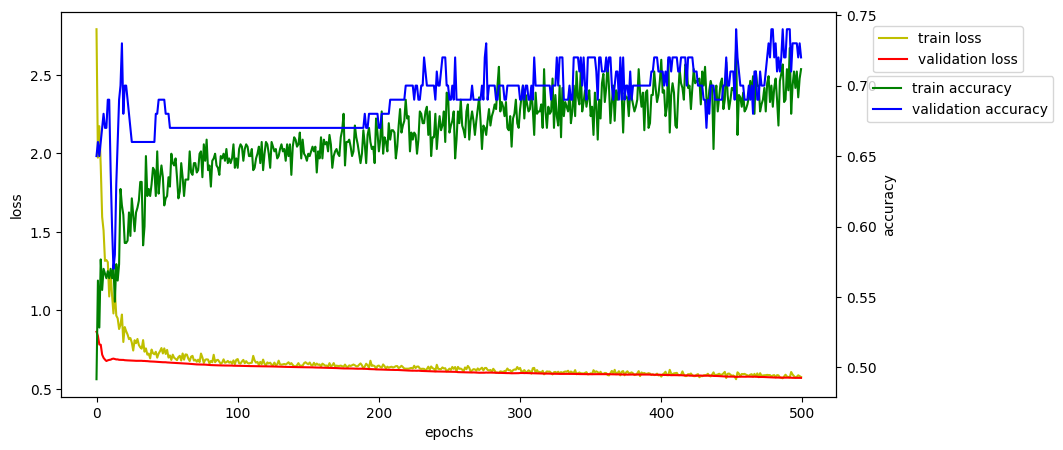

In [126]:
# 학습과정 표시- 그래프로 (학습데이터에 대한 loss / accuracy)

fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='validation loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), 'g', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), 'b', label='validation accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper right', bbox_to_anchor=(1.25,0.98))
acc_ax.legend(loc = 'upper right', bbox_to_anchor=(1.289,0.85))

### ※ 교차표 그리기

In [129]:
y_test  # == Y_test.argmax(axis=1)

array([0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
       0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.])

In [136]:
y_hat = model.predict(X_test)
y_hat.argmax(axis=1)

y_test.shape, y_hat.shape
y_hat

3/3 [==============================] - 0s 2ms/step


array([[0.6129927 , 0.3870073 ],
       [0.71076584, 0.28923413],
       [0.53424674, 0.46575326],
       [0.38454825, 0.61545175],
       [0.7690574 , 0.23094264],
       [0.7578912 , 0.24210885],
       [0.5346704 , 0.4653296 ],
       [0.5123855 , 0.48761457],
       [0.4588481 , 0.54115194],
       [0.65309846, 0.34690148],
       [0.47032154, 0.52967846],
       [0.80168754, 0.19831249],
       [0.47109085, 0.5289091 ],
       [0.5506432 , 0.44935673],
       [0.72414786, 0.27585208],
       [0.37696978, 0.6230302 ],
       [0.53077567, 0.4692243 ],
       [0.7703317 , 0.2296683 ],
       [0.6277363 , 0.3722637 ],
       [0.72051704, 0.27948296],
       [0.8551593 , 0.14484072],
       [0.61657083, 0.3834291 ],
       [0.6032224 , 0.3967776 ],
       [0.8185929 , 0.18140703],
       [0.8300394 , 0.16996059],
       [0.64961696, 0.35038307],
       [0.63494927, 0.36505073],
       [0.5842969 , 0.4157031 ],
       [0.51800543, 0.48199454],
       [0.59559995, 0.40440005],
       [0.

In [137]:
pd.crosstab(y_test, y_hat.argmax(axis=1))

col_0,0,1
row_0,,
0.0,39,2
1.0,19,8


## 2.6 모델 저장 및 사용

In [139]:
# model.save('model/06_pima.h5')
from tensorflow.keras.models import save_model, load_model
save_model(model, 'model/06_pima.h5')

In [142]:
model2 = load_model('model/06_pima.h5')

In [152]:
pred = model2.predict([[  6., 125.,78. ,31.   ,   0.   ,  27.6  ,   0.565, 49.   ],
                      [  2.   , 106.   ,  56.   ,  27.   , 165.   ,  29.   ,   0.426, 22.   ]])
pred.argmax(axis=1)

1/1 [==============================] - 0s 39ms/step


array([0, 0], dtype=int64)

In [148]:
X_test[1], y_test[1], X_test[33], y_test[33]

(array([  6.   , 125.   ,  78.   ,  31.   ,   0.   ,  27.6  ,   0.565,
         49.   ]),
 1.0,
 array([  2.   , 106.   ,  56.   ,  27.   , 165.   ,  29.   ,   0.426,
         22.   ]),
 0.0)

# 3. 연습문제
1. 데이터 셋 생성 & 전처리
```
    * 엑셀 -> 데이터프레임 -> ?처리 (df.replace('?', np.nan) -> 결측치처리
     -> X, y 분리 -> X 변수 스케일 조정 -> train_test_spilt
     (분류분석) -> y 변수들의 원핫인코딩
     
```
2. 모델 생성 (이진분석 : 입력 13, 출력 1   /   분류분석 : 입력 13, 출력 2)  # 분류분석은 원핫인코딩으로 출력수 증가
3. 모델 학습과정 설정 & 학습
4. 모델평가 (그래프, 평가, 교차표)
5. 모델 사용(저장, 예측)

In [160]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리

In [154]:
!pip install openpyxl

In [157]:
import openpyxl

In [159]:
pd.read_excel('data/heart-disease.xlsx')

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1
